<a href="https://colab.research.google.com/github/suryamanoj4/SMAI-A1/blob/main/SMAI_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Automated Essay Scoring System

Automate Essay Scoring(AES) system using handcrafted statistical features and K-Nearest-Neighbors (KNN) algorithm.

Dependencies

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
from scipy.spatial.distance import cosine, cdist

In [ ]:
class EssayFeatureExtractor:

    def __init__(self):
        self.abbreviations = {
            "mr.", "mrs.", "ms.", "dr.", "prof.", "sr.", "jr.",
            "st.", "vs.", "etc.", "e.g.", "i.e.",
            "a.m.", "p.m.",
            "fig.", "no.",
            "inc.",
            "jan.", "feb.", "mar.", "apr.", "jun.",
            "jul.", "aug.", "sep.", "sept.", "oct.",
            "nov.", "dec."
        }

    def _clean_text(self, text):
        """Clean text by replacing whitespace sequences with a single space."""
        return " ".join(str(text).split())

    def _split_sentences(self, text):
        """
        Split essay into sentences using character tracking.
        Protects abbreviations, initials, and decimal numbers.
        """
        text = self._clean_text(text)
        if not text:
            return []

        sentences = []
        current_sentence = []
        words_so_far = []

        i = 0
        n = len(text)

        while i < n:
            char = text[i]
            current_sentence.append(char)

            if char in ".!?":
                is_decimal = (
                    char == '.' and
                    i > 0 and text[i-1].isdigit() and
                    i + 1 < n and text[i+1].isdigit()
                )

                is_initial = (
                    char == '.' and
                    i > 0 and text[i-1].isalpha() and
                    (i == 1 or not text[i-2].isalpha())
                )

                is_abbreviation = False
                if char == '.':
                    temp_str = "".join(current_sentence).lower().split()
                    if temp_str:
                        last_token = temp_str[-1]
                        if last_token in self.abbreviations:
                            is_abbreviation = True

                if not (is_decimal or is_initial or is_abbreviation):
                    if i + 1 == n:
                        sentences.append("".join(current_sentence).strip())
                        current_sentence = []
                    elif i + 1 < n and text[i+1] == ' ':
                        j = i + 1
                        while j < n and text[j] == ' ':
                            j += 1
                        if j < n and (text[j].isupper() or text[j].isdigit() or text[j] in '"\''):
                            sentences.append("".join(current_sentence).strip())
                            current_sentence = []
                            i = j - 1

            i += 1

        if current_sentence:
            remaining = "".join(current_sentence).strip()
            if remaining:
                sentences.append(remaining)

        return [s for s in sentences if s]

    def _tokenize_words(self, text):
        """
        Extract word tokens from scratch without regex.
        Handles inner apostrophes (e.g., "don't", "essay's").
        """
        text = text.lower()
        words = []
        current_word = []

        for i, char in enumerate(text):
            if char.isalpha():
                current_word.append(char)
            elif char == "'" and current_word:
                if i + 1 < len(text) and text[i+1].isalpha():
                    current_word.append(char)
                else:
                    words.append("".join(current_word))
                    current_word = []
            else:
                if current_word:
                    words.append("".join(current_word))
                    current_word = []

        if current_word:
            words.append("".join(current_word))

        return words

    def extract_features(self, essay):
        """Extract statistical features from an essay."""

        essay = self._clean_text(essay)
        sentences = self._split_sentences(essay)
        words = self._tokenize_words(essay)
        word_count = len(words)
        sentence_count = len(sentences)

        short_words = sum(len(word) < 4 for word in words)
        medium_words = sum(4 <= len(word) <= 10 for word in words)
        long_words = sum(len(word) > 10 for word in words)

        unique_words = len(set(words))

        sentence_word_counts = [
            len(self._tokenize_words(sentence))
            for sentence in sentences
        ]

        short_sentences = sum(count < 4 for count in sentence_word_counts)
        medium_sentences = sum(4 <= count <= 10 for count in sentence_word_counts)
        long_sentences = sum(count > 10 for count in sentence_word_counts)

        word_density = (
            word_count / sentence_count
            if sentence_count > 0
            else 0
        )

        word_frequency = Counter(words)
        repeat_frequency = sum(
            count - 1
            for count in word_frequency.values()
            if count > 1
        )

        features = {
            'word_count': word_count,
            'sentence_count': sentence_count,
            'short_words': short_words,
            'medium_words': medium_words,
            'long_words': long_words,
            'unique_words': unique_words,
            'short_sentences': short_sentences,
            'medium_sentences': medium_sentences,
            'long_sentences': long_sentences,
            'word_density': word_density,
            'repeat_frequency': repeat_frequency
        }

        return features

# Features and their reasoning

---

## Word Level

* **`word_count`** - Total no of word in essay
* **`short_words`** - short words < 4 characters
* **`medium_words`** - word in between 4-20 characters
* **`long_words`** - word with >10 characters
* **`unique_words`** - count of unique words in essay
* **`repeat_frequency`** - Sum of duplicates of every word

---

## Sentence Level

* **`sentence_count`** - total no of sentences in an essay
* **`short_sentences`** - sentences with < 4 words
* **`medium_words`** - sentences with 4-10 words
* **`long_words`** - sentences with > 10 words
* **`word_density`** - average no of words in sentences in the essay

---

The ranges for the definition of short words and sentences is derived from some experiments where i have found if word length is less than 4 the only words that satisty these are conjunctions and it did not show much correction with score so 4 seems like a reasonable range to define short shorts with good coverage in vocabulary.


In [ ]:
class Dataset:
  def __init__(self, path):
    self.path = path
    self.df = pd.read_csv(path)
    self.feature_means = None
    self.feature_stds = None

  def feature_extraction(self):
    """extract features from the essays"""
    extractor = EssayFeatureExtractor()
    feature_df = self.df["full_text"].apply(extractor.extract_features).apply(pd.Series)
    normalized_feature_df = self.feature_normalization(feature_df, store_params=True)
    self.df = pd.concat([self.df, normalized_feature_df], axis=1)
    return self.df

  def feature_normalization(self, df, stored_mean=None, stored_std=None, store_params=False):
    """Normalize features to same scale: using Z-score standardization.
    Optionally use stored mean and std for normalization, or store them if store_params is True."""
    if stored_mean is None or stored_std is None:
        # Calculate mean and std from the provided df
        if store_params:
            self.feature_means = df.mean()
            self.feature_stds = df.std()
        normalized_df = (df - df.mean()) / df.std()
    else:
        # Use stored mean and std for normalization (for new data)
        normalized_df = (df - stored_mean) / stored_std
    return normalized_df

  def train_val_test_split(self, feature_columns, target_column, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=None):
    """Custom train val test splitting with ramdom sampling"""
    if not (train_ratio + val_ratio + test_ratio == 1.0):
        raise ValueError("Train, validation, and test ratios must sum to 1.0")

    if random_state is not None:
        np.random.seed(random_state)

    # Shuffle the DataFrame
    shuffled_df = self.df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Separate features (X) and target (y)
    X = shuffled_df[feature_columns]
    y = shuffled_df[target_column]

    total_samples = len(shuffled_df)
    train_end = int(train_ratio * total_samples)
    val_end = train_end + int(val_ratio * total_samples)

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_val = X.iloc[train_end:val_end]
    y_val = y.iloc[train_end:val_end]

    X_test = X.iloc[val_end:]
    y_test = y.iloc[val_end:]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
# Check the new dataset with the normalized extracted features
dataset = Dataset("/content/essays(in).csv")
df = dataset.feature_extraction()
df.head()

,essay_id,full_text,score,word_count,sentence_count,short_words,medium_words,long_words,unique_words,short_sentences,medium_sentences,long_sentences,word_density,repeat_frequency
0,000d118,Many people have car where they live. The thin...,3,0.873609,-0.144240,1.003161,0.727134,0.965708,1.013964,-0.220045,-0.002075,-0.159474,-0.030250,0.744495
1,000fe60,I am a scientist at NASA that is discussing th...,3,-0.233335,0.240329,0.052703,-0.386131,-0.872647,-0.401620,-0.220045,-0.002075,0.308643,-0.332821,-0.130573
2,001ab80,People always wish they had the same technolog...,4,1.227031,0.881277,1.325351,1.079289,1.374232,1.125720,-0.220045,-0.392385,1.244878,-0.238245,1.201475
3,001bdc0,"We all heard about Venus, the planet without a...",4,0.533524,0.112139,0.310455,0.624895,1.169970,0.864955,-0.220045,-0.392385,0.308643,-0.176863,0.326407
4,002ba53,"Dear, State SenatorThis is a letter to argue i...",3,0.060072,-0.528809,0.246017,-0.136214,1.169970,-0.494750,-0.220045,-0.782696,-0.315513,-0.042445,0.345853


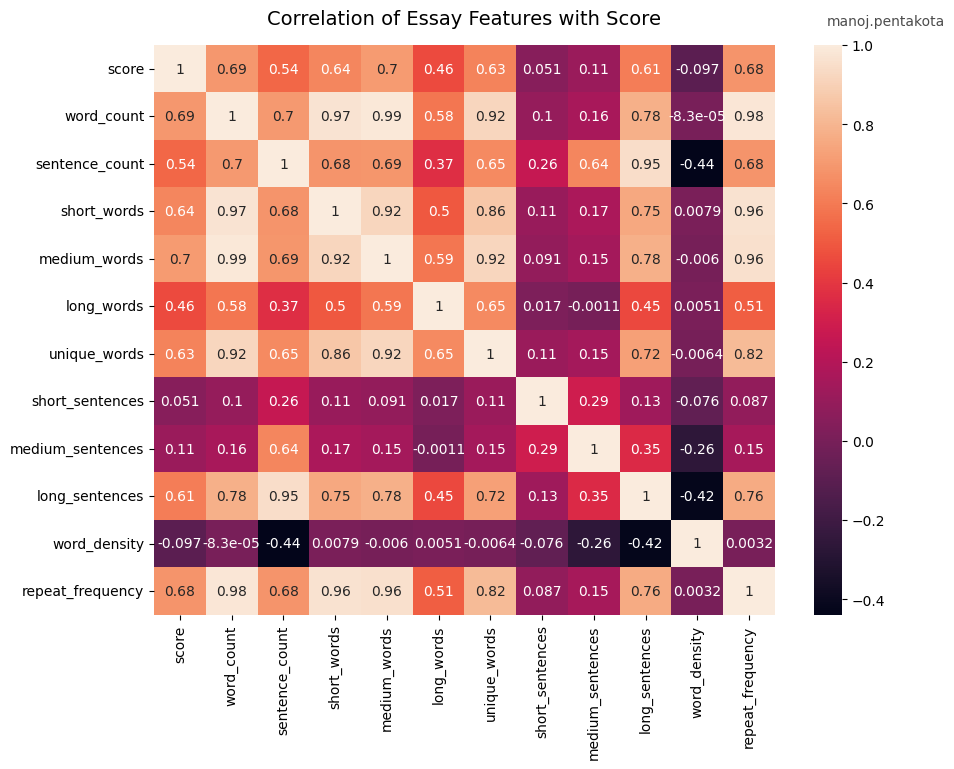

In [ ]:
#confusion matrix for correlation between score and features

feature_cols = [
    'score', 'word_count', 'sentence_count', 'short_words',
    'medium_words', 'long_words', 'unique_words',
    'short_sentences', 'medium_sentences', 'long_sentences',
    'word_density', 'repeat_frequency'
]

corr_matrix = df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation of Essay Features with Score', fontsize=14, pad=15)
plt.text(0.95, 0.95, "manoj.pentakota",ha='right',va='top',transform=plt.gcf().transFigure, fontsize=10,alpha=0.7)
plt.show
plt.tight_layout()
plt.show()

From the above heatmap, we can observe the correlation between the individual features and the score.

Based on the observation:

* **word_count**, **sentence_count**, **medium_words**, **unique_words**, **long_sentences**, and **repeat_frequency** are having more correlation with the score. This indicates that these features have a relatively stronger relationship with the overall score compared to the other features.
* Whereas **short_sentences**, **medium_sentences**, and **word_density** have the least correlation with the score. Among these features, **word_density** is showing a negative correlation with the score.
* Overall, the heatmap helps us identify which individual features have a stronger or weaker correlation with the score and can therefore be considered when analyzing the relationship between the essay features and the final score.


/tmp/ipykernel_569/1330114330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='score', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_569/1330114330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='score', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_569/1330114330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='score', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_569/1330114330.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.1

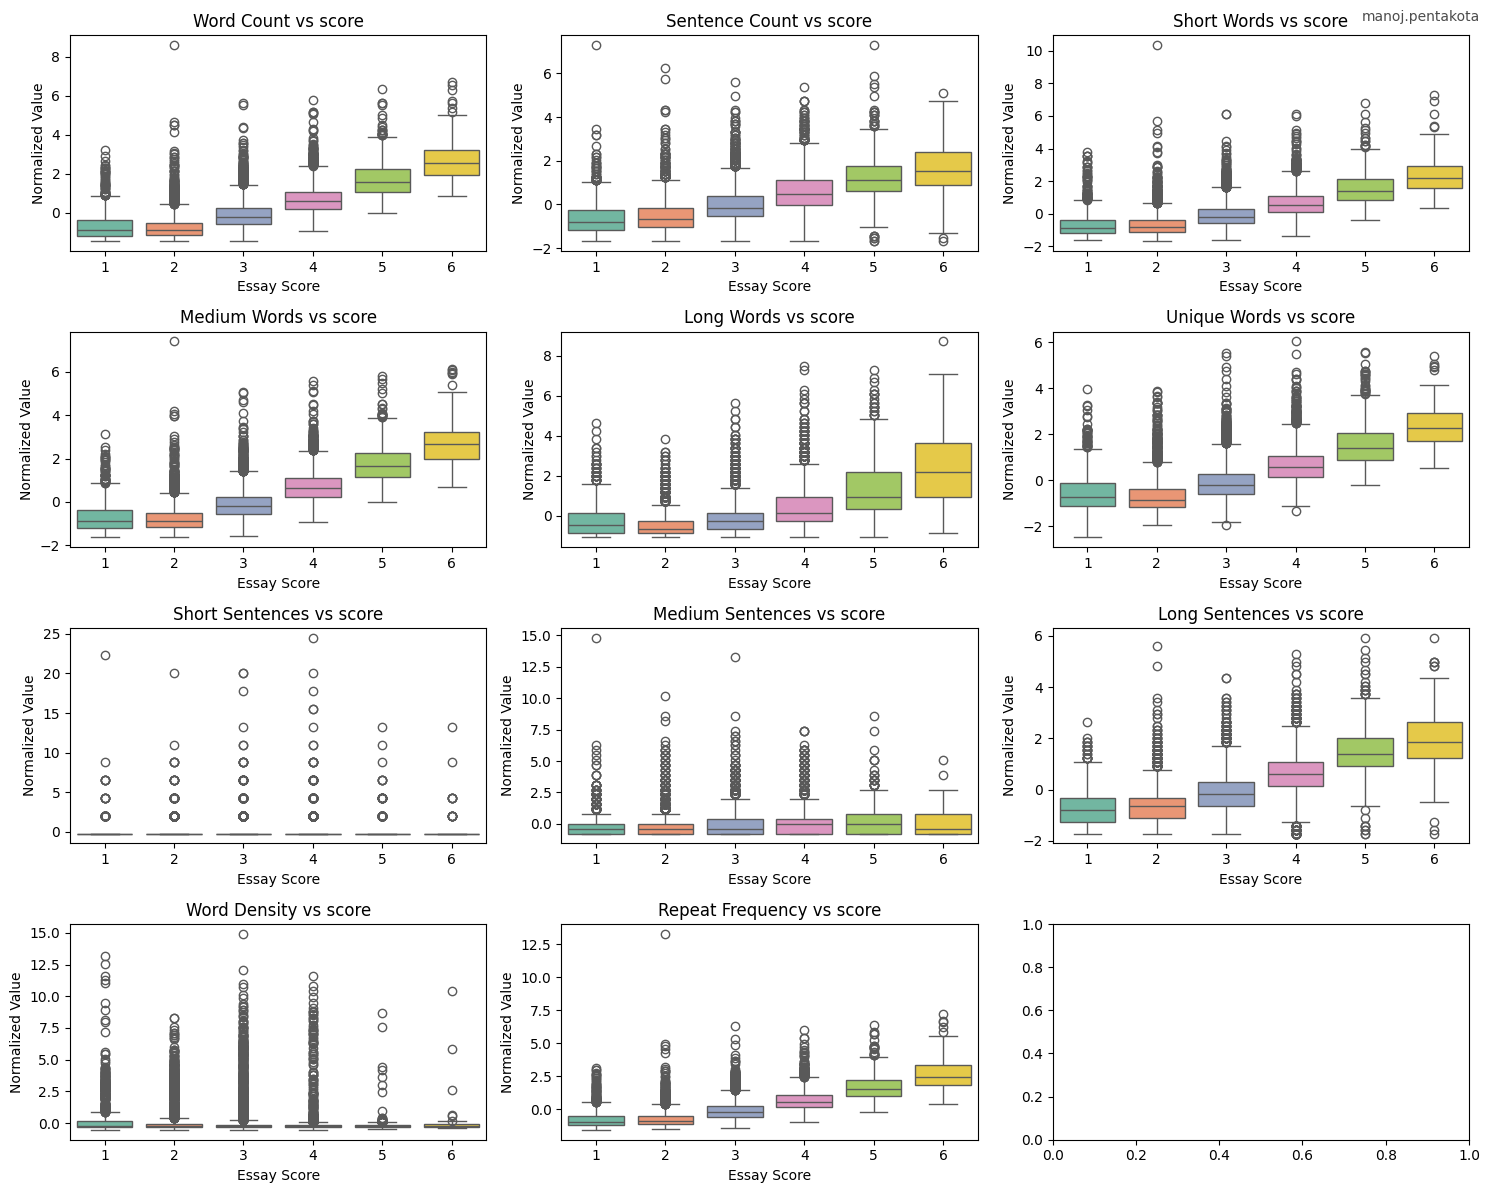

In [ ]:
# box plots for per feature to score relation

features_to_plot = [col for col in feature_cols  if col!= "score"]
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i,col in enumerate(features_to_plot):
    sns.boxplot(x='score', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col.replace("_", " ").title()} vs score')
    axes[i].set_xlabel('Essay Score')
    axes[i].set_ylabel('Normalized Value')

fig.text(0.99, 0.99, "manoj.pentakota",ha='right',va='top',transform=plt.gcf().transFigure, fontsize=10,alpha=0.7)

plt.tight_layout()
plt.show()


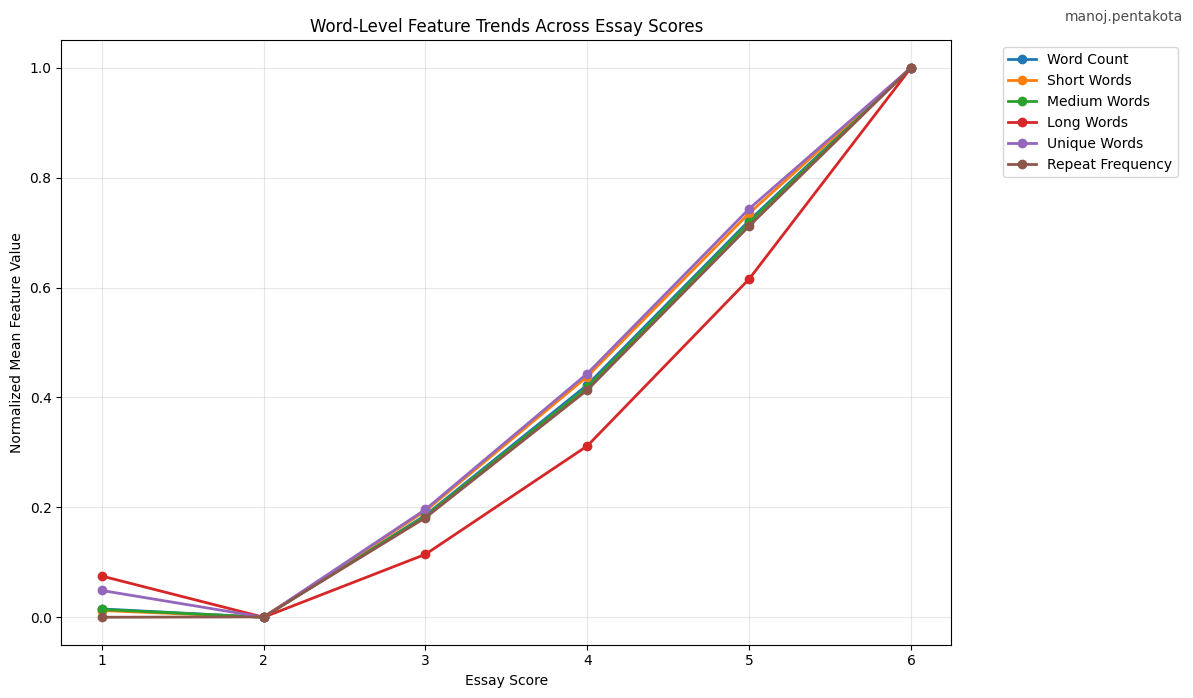

In [ ]:
# word level features trends across score range

word_features = [
    'word_count',
    'short_words',
    'medium_words',
    'long_words',
    'unique_words',
    'repeat_frequency'
]
plt.figure(figsize=(12, 7))
for feature in word_features:
    mean_values = df.groupby('score')[feature].mean()
    # Normalize so features with different scales can be compared
    mean_values = (
        mean_values - mean_values.min()
    ) / (
        mean_values.max() - mean_values.min()
    )
    plt.plot(
        mean_values.index,
        mean_values.values,
        marker='o',
        linewidth=2,
        label=feature.replace('_', ' ').title()
    )
plt.title('Word-Level Feature Trends Across Essay Scores')
plt.xlabel('Essay Score')
plt.ylabel('Normalized Mean Feature Value')
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.grid(alpha=0.3)
plt.figtext(
    0.99, 0.99,
    "manoj.pentakota",
    ha='right',
    va='top',
    fontsize=10,
    alpha=0.7
)
plt.tight_layout()
plt.show()

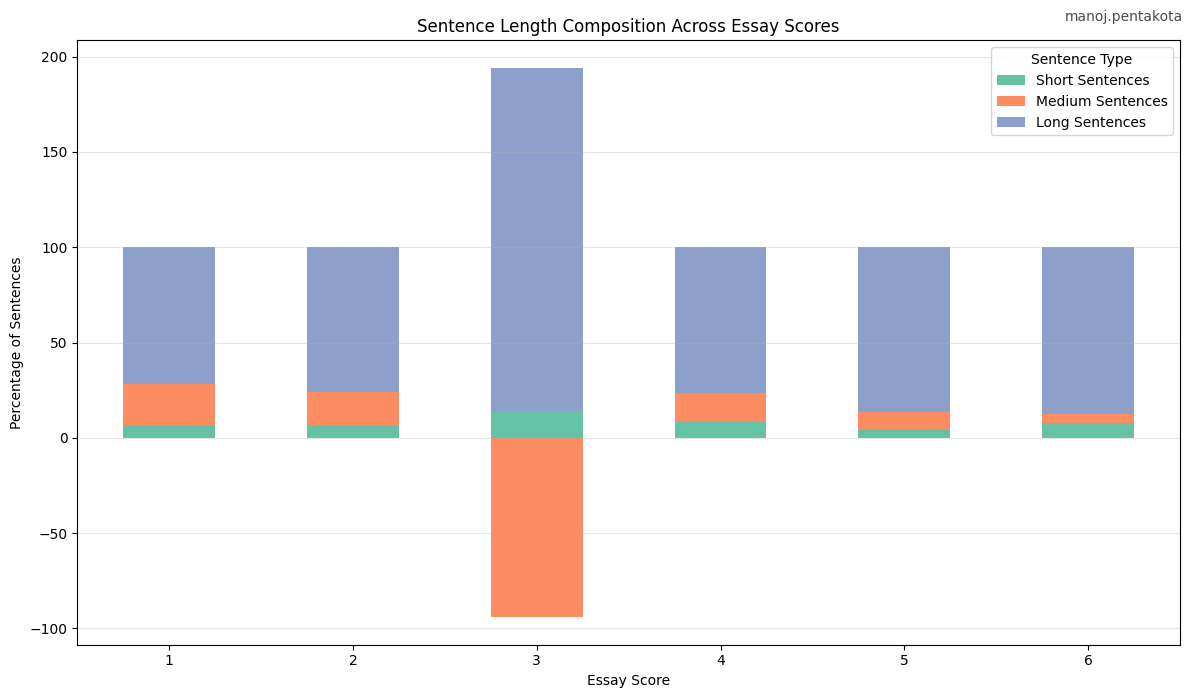

In [ ]:
#sentence lenth percentages across scores

sentence_features = [
    'short_sentences',
    'medium_sentences',
    'long_sentences'
]
sentence_counts = df.groupby('score')[sentence_features].mean()
# Convert counts into proportions
sentence_proportions = (
    sentence_counts.div(
        sentence_counts.sum(axis=1),
        axis=0
    ) * 100
)
ax = sentence_proportions.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    color=['#66c2a5', '#fc8d62', '#8da0cb']
)
plt.title('Sentence Length Composition Across Essay Scores')
plt.xlabel('Essay Score')
plt.ylabel('Percentage of Sentences')
plt.legend(
    title='Sentence Type',
    labels=[
        'Short Sentences',
        'Medium Sentences',
        'Long Sentences'
    ]
)
plt.xticks(rotation=0)
plt.grid(
    axis='y',
    alpha=0.3
)
plt.figtext(
    0.99, 0.99,
    "manoj.pentakota",
    ha='right',
    va='top',
    fontsize=10,
    alpha=0.7
)
plt.tight_layout()
plt.show()

In [ ]:
class KNN:
  def __init__(self, k=5, distance='euclidean'):
    self.k = k
    self.distance = distance
    self.X_train = None
    self.y_train = None

  def fit(self, X_train, y_train):
    """store the training feature vectors and scores"""
    # convert inputs to numpy arrays for fast vector math
    self.X_train = np.array(X_train)
    self.y_train = np.array(y_train)

  def _compute_distance(self, x):
    """calculate distance between given point and all training points """
    # Ensure inputs are float for distance calculations
    x = np.asarray(x, dtype=float)
    X_train_float = np.asarray(self.X_train, dtype=float)

    if self.distance == 'euclidean':
      return np.sqrt(np.sum((X_train_float - x)**2, axis=1))
    elif self.distance == 'manhattan':
      return np.sum(np.abs(X_train_float - x), axis=1)
    elif self.distance == 'cosine':
      # cdist computes distances between each pair of the two collections of inputs.
      # We want distance between a single point x and all points in X_train.
      # x needs to be reshaped to (1, n_features) for cdist.
      return cdist(x.reshape(1, -1), X_train_float, metric='cosine')[0]
    else:
      raise ValueError(f"Invalid distance metric: '{self.distance}'. Supported: 'euclidean', 'manhattan', 'cosine'")

  def predict(self, X_test):
    """predict essay scores for given feature vector"""
    X_test = np.array(X_test)
    return np.array([self._predict_single(x) for x in X_test])

  def _predict_single(self, x):
    """helper to predict for single point"""
    distances = self._compute_distance(x)
    k_indices = np.argsort(distances)[:self.k]
    k_nearest_distances = distances[k_indices]
    k_nearest_labels = self.y_train[k_indices]

    # Give closer neighbours bore influence
    weights = 1/ (k_nearest_distances  + 1e-8)

    weighted_predictions = np.sum(weights * k_nearest_labels)/np.sum(weights)
    # Round final prefiction to integer
    return int(np.round(weighted_predictions))

Here for the distance calculation in the KNN implementation we have implemented distance weights classification where rather than direct clasHere, for the distance calculation in the KNN implementation, we have implemented **distance-weighted classification**. Rather than performing direct classification using the average score of the nearest neighbors, this distance-weighted approach gives more influence to the closer neighbors.

In this approach, the contribution of each neighbor is determined based on its distance from the given data point. Neighbors that are closer have a higher weight and therefore have a greater influence on the final predicted score, while farther neighbors have a relatively lower influence. This allows the prediction to be more representative of the most similar data points rather than treating all selected neighbors equally.
sification with avg score of the nearest , this distance weighted aproach gives more influennce to the closer neighours.

In [1]:
class Evaluation:
    def __init__(self):
        pass

    def calculate_mae(self, y_true, y_pred):
        """Calculates Mean Absolute Error (MAE)."""
        return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

    def calculate_rmse(self, y_true, y_pred):
        """Calculates Root Mean Squared Error (RMSE)."""
        return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))

    def calculate_r2_score(self, y_true, y_pred):
        """Calculates R-squared (R2) score."""
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        ss_total = np.sum((y_true - np.mean(y_true))**2)
        ss_residual = np.sum((y_true - y_pred)**2)
        # Avoid division by zero if ss_total is zero (all true values are identical)
        if ss_total == 0:
            return 1.0 if ss_residual == 0 else 0.0 # Perfect fit if residuals are also zero
        return 1 - (ss_residual / ss_total)

    def calculate_pearson_correlation(self, y_true, y_pred):
        """Calculates Pearson Correlation Coefficient."""
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        mean_y_true = np.mean(y_true)
        mean_y_pred = np.mean(y_pred)
        numerator = np.sum((y_true - mean_y_true) * (y_pred - mean_y_pred))
        denominator = np.sqrt(np.sum((y_true - mean_y_true)**2) * np.sum((y_pred - mean_y_pred)**2))
        # Avoid division by zero
        if denominator == 0:
            return 0.0
        return numerator / denominator


In [ ]:
import hashlib
username = "manoj.pentakota"
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

In [ ]:
# split dataset into train val test splits

# Define the feature columns and target column
feature_cols_for_model = [
    'word_count', 'sentence_count', 'short_words',
    'medium_words', 'long_words', 'unique_words',
    'short_sentences', 'medium_sentences', 'long_sentences',
    'word_density', 'repeat_frequency'
]
target_col = 'score'

# Perform the custom train, validation, and test split
X_train, y_train, X_val, y_val, X_test, y_test = dataset.train_val_test_split(
    feature_columns=feature_cols_for_model,
    target_column=target_col,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=seed
)

print(f"Training set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 12114 samples
Validation set size: 2596 samples
Test set size: 2597 samples


In [ ]:
# Abalation study on on the model performance with different hyper parameters

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
distance_metrics = ['euclidean', 'manhattan', 'cosine']

# Initialize the Evaluation class
evaluator = Evaluation()

results = []

for k in k_values:
    for dist_metric in distance_metrics:
        print(f"Testing K={k}, Distance='{dist_metric}'...")

        # Initialize and fit the KNN model
        knn_model = KNN(k=k, distance=dist_metric)
        knn_model.fit(X_train, y_train)

        # Make predictions on the validation set
        y_pred_val = knn_model.predict(X_val)

        # Calculate evaluation metrics
        mae = evaluator.calculate_mae(y_val, y_pred_val)
        rmse = evaluator.calculate_rmse(y_val, y_pred_val)
        r2 = evaluator.calculate_r2_score(y_val, y_pred_val)
        pearson_corr = evaluator.calculate_pearson_correlation(y_val, y_pred_val)

        # Store results
        results.append({
            'K': k,
            'Distance': dist_metric,
            'MAE': mae,
            'RMSE': rmse,
            'R2 Score': r2,
            'Pearson Correlation': pearson_corr
        })
# Convert results to a DataFrame for better readability
results_df = pd.DataFrame(results)

# Sort by MAE (lower is better) to easily find the best models
results_df_sorted = results_df.sort_values(by='MAE').reset_index(drop=True)
display(results_df_sorted)

Testing K=1, Distance='euclidean'...
Testing K=1, Distance='manhattan'...
Testing K=1, Distance='cosine'...
Testing K=3, Distance='euclidean'...
Testing K=3, Distance='manhattan'...
Testing K=3, Distance='cosine'...
Testing K=5, Distance='euclidean'...
Testing K=5, Distance='manhattan'...
Testing K=5, Distance='cosine'...
Testing K=7, Distance='euclidean'...
Testing K=7, Distance='manhattan'...
Testing K=7, Distance='cosine'...
Testing K=9, Distance='euclidean'...
Testing K=9, Distance='manhattan'...
Testing K=9, Distance='cosine'...
Testing K=11, Distance='euclidean'...
Testing K=11, Distance='manhattan'...
Testing K=11, Distance='cosine'...
Testing K=15, Distance='euclidean'...
Testing K=15, Distance='manhattan'...
Testing K=15, Distance='cosine'...
Testing K=21, Distance='euclidean'...
Testing K=21, Distance='manhattan'...
Testing K=21, Distance='cosine'...


,K,Distance,MAE,RMSE,R2 Score,Pearson Correlation
0,21,manhattan,0.501156,0.776435,0.462152,0.688873
1,21,euclidean,0.510786,0.784578,0.450811,0.680171
2,15,manhattan,0.511171,0.783349,0.452529,0.683409
3,11,manhattan,0.513867,0.786539,0.448062,0.681382
4,15,euclidean,0.516949,0.786049,0.448749,0.680106
5,9,manhattan,0.518105,0.795548,0.435346,0.674942
6,7,manhattan,0.520031,0.793852,0.437751,0.676791
7,21,cosine,0.520416,0.795064,0.436033,0.678140
8,11,euclidean,0.522727,0.793123,0.438783,0.675148
9,15,cosine,0.523498,0.799894,0.429160,0.675316


From the above **ablation study** with different hyperparameters, specifically **distance metrics** and **K values**, we can observe the performance of the KNN implementation across thousands of samples.

The results show that our **performance increases proportionally with K**, indicating that considering more nearest neighbors generally improves the prediction performance. However, **cosine distance** has clearly performed worse compared with both **Manhattan** and **Euclidean** distance.

On the other hand, **Manhattan and Euclidean distances perform very closely**, with no significant difference in their performance across the different values of K. Therefore, based on these results, Manhattan and Euclidean distance can be considered **interchangeable in terms of performance** for our implementation.


In [ ]:
# Final evaluations on the test set

# Get the best hyperparameters from the tuning results
best_params = results_df_sorted.iloc[0]
best_k = int(best_params['K'])
best_distance = best_params['Distance']

print(f"\nBest K: {best_k}, Best Distance: '{best_distance}'")

# Initialize and fit the KNN model with the best hyperparameters on the training data
best_knn_model = KNN(k=best_k, distance=best_distance)
best_knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_test = best_knn_model.predict(X_test)

# Initialize the Evaluation class
evaluator = Evaluation()

# Calculate evaluation metrics for the test set
mae_test = evaluator.calculate_mae(y_test, y_pred_test)
rmse_test = evaluator.calculate_rmse(y_test, y_pred_test)
r2_test = evaluator.calculate_r2_score(y_test, y_pred_test)
pearson_corr_test = evaluator.calculate_pearson_correlation(y_test, y_pred_test)

print("\n--- Final Evaluation on Test Set ---")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"R2 Score: {r2_test:.4f}")
print(f"Pearson Correlation Coefficient: {pearson_corr_test:.4f}")

# Display first 5 predictions on test data (optional, but good for quick check)
print("\nFirst 5 predictions on test data:")
print(y_pred_test[:5])
print("First 5 actual labels from test data:")
print(y_test[:5].values)


Best K: 21, Best Distance: 'manhattan'

--- Final Evaluation on Test Set ---
Mean Absolute Error (MAE): 0.4863
Root Mean Squared Error (RMSE): 0.7597
R2 Score: 0.4731
Pearson Correlation Coefficient: 0.6947

First 5 predictions on test data:
[2 2 2 2 4]
First 5 actual labels from test data:
[3 2 2 2 6]


From the results on the test split we can observe that the model is performing better on test split than on val split. and from the examples on test data we cna observe in some cases the model is not able to estimate further points.

# 2. **Probability Basics and Bayesian Learning**


# 2.1 Sampling tool

In [ ]:
# Uniform Generator (LCG)

import numpy as np

def lcg_uniform_generator(low, high, num_samples, seed):
  """
  linear congruential generator via MINSTD recurrence
  """
  a = 48271
  m = 2**31 -1

  # initialize state to seed % m and make sure it is not 0
  state = seed % m
  if state == 0:
    state = 1

  # iterate the recurrence and store state / m
  samples = []
  for _ in range(num_samples):
    state = (a * state) % m
    samples.append(state / m)

  # convert samples to np array and scale to [low,high)
  samples = np.array(samples)
  scaled_samples = low + (high-low)*samples
  return scaled_samples

In [ ]:
import hashlib
username = "manoj.pentakota" # You can replace this with a dynamic username if available
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

print(lcg_uniform_generator(10, 100, 8, seed))

[99.4521653  25.47141005 10.43433459 95.76500847 62.72376228 18.72891413
 73.41418856 86.29619612]


Example generation with uniform generator, we can observe that the generated values lie in the (low, high) range

In [ ]:
# Gaussian Sampler
# y = F(x) = 1/2 [1 + erf(x-mu)/sigma sqrt(2)]

import numpy as np
from scipy.special import erfinv

def inverse_cdf_gaussian(y, mu, sigma):
  """
  x = sigma * sqrt(2) * erfinv(2*y - 1) + mu
  """
  return sigma * np.sqrt(2) * erfinv(2*y - 1) + mu

def gaussian_generator(mu, sigma, num_samples, seed):
  """returns gaussian samples from uniform samples from lcg_uniform_generator"""
  uniform_samples = lcg_uniform_generator(0, 1, num_samples, seed)
  gaussian_samples = inverse_cdf_gaussian(uniform_samples, mu, sigma)

  return gaussian_samples

In [ ]:
print(gaussian_generator(4, 2, 4, seed))

[ 9.0141142   2.10666844 -1.1761155   7.34820025]


With gaussian as we are generating around a central mean gaussian generator can generate negatives too depending on the mean and variance.

In [ ]:
# Binomial Sampler

import numpy as np
from scipy.special import comb

def binomial_pmf(k, n, p):
  """
  PMF of binomial(n,p) variable
  px^k = (n k)p^k(1-p)^n-k
  """
  # ensure p is between 0 and 1
  if not 0<=p<=1:
    raise ValueError("p must be between 0 and 1")

  return comb(n, k, exact=False)* p**k * (1-p)**(n-k)

def binomial_quantile(y, n, p):
  """
  quantile function (inverse CDF) for binomial distribution
  Q(y) = min{k E {0,....,n} : F(k) >= y}
  """

  k_vals = np.arange(n+1)
  pmf = binomial_pmf(k_vals, n, p)
  cdf = np.cumsum(pmf)
  return np.searchsorted(cdf, y)

def binomial_generator(n, p, num_samples, seed):
  """returns binomial samples from uniform samples from lcg_uniform_generator"""
  uniform_samples = lcg_uniform_generator(0, 1, num_samples, seed)
  binomial_samples = binomial_quantile(uniform_samples, n, p)

  return binomial_samples

In [ ]:
print(binomial_generator(100, 0.7, 4, seed))

[81 66 58 78]


Binomial generator unlike the uniform and gaussian generate discrete values rather than how uniform and gaussian generate from continuos values.

In [ ]:
# Image Sampler  -- Sampling a 2D empirical density
import numpy as np

def row_marginal(image):
  """
  computes P(row) = sum_col(image[row,col]/ sum(image))
  """
  row_sums = np.sum(image, axis=1)
  total_sum = np.sum(image)
  return row_sums / total_sum

def col_conditional(image, row):
  """
  computes P(col|row) = image[row,:]/sum_col(image[row:])
  """
  row_slice = image[row, :]
  row_sum = np.sum(row_slice)

  return row_slice / row_sum

def image_generator(image, num_samples, seed):
  """samples (row, col) pairs from 2d image density"""

  p_rows = row_marginal(image)
  row_cdf = np.cumsum(p_rows)
  row_cdf[-1] = 1.0

  # generate 2*num_samples uniform samples
  # alternating indices even for row and odd for cols
  u_vals = lcg_uniform_generator(0, 1, 2*num_samples, seed)

  samples = []

  for i in range(num_samples):
    u_row = u_vals[2*i]
    u_col = u_vals[2*i + 1]

    # sample a row
    row = int(np.searchsorted(row_cdf, u_row))

    # sample a col
    p_col_given_row = col_conditional(image, row)
    col_cdf = np.cumsum(p_col_given_row)
    col_cdf[-1] = 1.0

    col = int(np.searchsorted(col_cdf, u_col))

    samples.append((row, col))

  return np.array(samples)

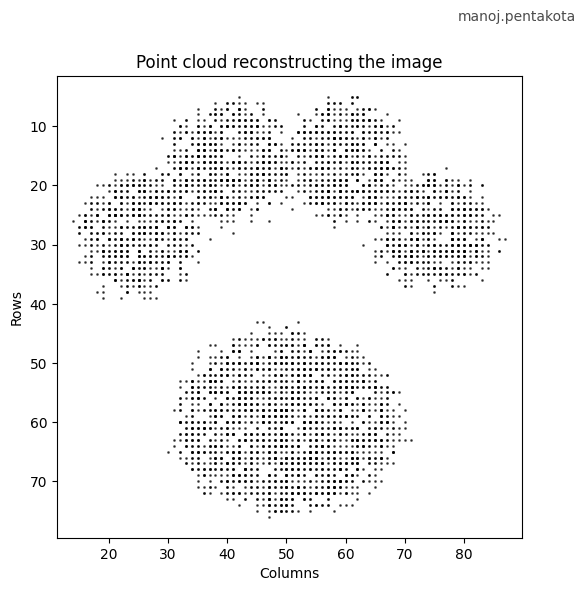

In [ ]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import hashlib

file_path = "/content/paw_print.png"
img_matrix = mpimg.imread(file_path)

if img_matrix.ndim == 3:
    # average the color channels for 2 intensity grid
    img_matrix = img_matrix.mean(axis=2)

num_samples = 5000
username = "manoj.pentakota" # You can replace this with a dynamic username if available
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
samples = image_generator(img_matrix, num_samples=num_samples, seed=seed)

rows = samples[:, 0]
cols = samples[:, 1]

plt.figure(figsize=(6,6))
plt.scatter(cols,rows,s=1,color='black',alpha=0.6)
plt.gca().invert_yaxis()

plt.title(f"Point cloud reconstructing the image")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.figtext(
    0.99, 0.99,
    "manoj.pentakota",
    ha='right',
    va='top',
    fontsize=10,
    alpha=0.7
)
plt.axis('equal')

plt.show()

In [ ]:
# 2.1.5 Generator validation

import numpy as np
import scipy.special as sp
import hashlib

def emprical_cdf(sample, x):
  """
  compute the fraction of samples <= x
  f_hat(x) = 1/n* sum(sample <= x_i)
  """
  sample = np.asarray(sample)
  x = np.asarray(x)
  return np.mean(sample <= x[:, None], axis=1)

def max_cdf_distance(sample, cdf_function, eval_points):
  """
  calculates max_j |f_hat(t_j) - f(t_j)| over evaluation points
  """
  emprical_vals = emprical_cdf(sample, eval_points)

  if callable(cdf_function):
    theoretical_vals = cdf_function(eval_points)
  else:
    theoretical_vals = np.asarray(cdf_function)

  return np.max(np.abs(emprical_vals - theoretical_vals))


# Theoretical CDF eval functions

def uniform_theoretical_cdf(x, low=0.0, high=1.0):
  """theoretical cdf for uniform distribution"""
  return np.clip((x-low)/(high-low), 0.0, 1.0)

def gaussian_theoretical_cdf(x, mu=0.0, sigma=1.0):
  """theoretical cdf for gaussian distribution"""
  return 0.5 * (1 + sp.erf((x-mu)/(sigma*np.sqrt(2))))

def binomial_theoretical_cdf(eval_points, n, p):
  """theoretical cdf for binomial distribution"""
  eval_points = np.asarray(eval_points)
  k_vals = np.arange(n+1)
  pmf = binomial_pmf(k_vals, n, p)
  full_cdf = np.cumsum(pmf)

  cdf_vals = []
  for val in eval_points:
    if val < 0:
      cdf_vals.append(0.0)
    elif val >= n:
      cdf_vals.append(1.0)
    else:
      cdf_vals.append(full_cdf[int(np.floor(val))])

  return np.array(cdf_vals)

# ----- generator validation runs ------

num_val_samples = 10000

username = "manoj.pentakota" # You can replace this with a dynamic username if available
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

# uniform generator validation
low_u, high_u = 0.0, 1.0
u_samples = lcg_uniform_generator(low_u, high_u, num_val_samples, seed)
eval_u = np.linspace(-0.2, 1.2, 100)
D_uniform = max_cdf_distance(u_samples, lambda x: uniform_theoretical_cdf(x, low_u, high_u), eval_u)

# gaussian sampler validation
mu_g, sigma_g = 0.0, 1.0
g_samples = gaussian_generator(mu_g, sigma_g, num_val_samples, seed)
eval_g = np.linspace(-4.0, 4.0, 100)
D_gaussian = max_cdf_distance(g_samples, lambda x: gaussian_theoretical_cdf(x, mu_g, sigma_g), eval_g)

# binomial sampler validation
n_b, p_b = 20, 0.4
b_sampler = binomial_generator(n_b, p_b, num_val_samples, seed)
eval_b = np.arange(-1, n_b +2)
D_binomial = max_cdf_distance(b_sampler, lambda x: binomial_theoretical_cdf(x, n_b, p_b), eval_b)

print(f"Max CDF Distance (D) for Uniform: {D_uniform:.5f}")
print(f"Max CDF Distance (D) for Gaussian: {D_gaussian:.5f}")
print(f"Max CDF Distance (D) for Binomial: {D_binomial:.5f}")

Max CDF Distance (D) for Uniform: 0.00609
Max CDF Distance (D) for Gaussian: 0.00510
Max CDF Distance (D) for Binomial: 0.00276


In [ ]:
#2.1.4 (d)

# compute true theoretical row CDF from the image matrix
true_row_p = row_marginal(img_matrix)
true_row_cdf = np.cumsum(true_row_p)

# evaluation points for all rows
eval_rows = np.arange(img_matrix.shape[0])

# 3. Calculate max CDF distance D using 2.1.5's max_cdf_distance
D_row_marginal = max_cdf_distance(rows, true_row_cdf, eval_rows)

print(f"Max CDF Distance (D) for Row Marginal: {D_row_marginal:.5f}")

Max CDF Distance (D) for Row Marginal: 0.00898


2.2 Naive Bayes Classifier for Mixed Features

In [ ]:
# 2.2.1 Maximum-Likelihood Estimators

def mle_gaussian(x):
  """
  MLe for gaussian distribution
  mu_hat = mean(x)
  sigma_hat = sqrt((1/n)* sum(x_i - mean)^2)
  """
  x = np.asarray(x, dtype=float)
  mu_hat = float(np.mean(x))
  sigma_hat = float(np.sqrt(np.mean((x - mu_hat)**2)))
  return mu_hat, sigma_hat

def mle_binomial(x, n):
  """
  mle for binomial distribution
  p_hat = mean(x) / n
  """
  x = np.asarray(x, dtype=float)
  p_hat = float(np.mean(x) / n)
  return p_hat

def mle_uniform(x):
  """
  mle for uniform distribution
  a_hat = min(x)
  b_hat = max(x)
  """
  x = np.asarray(x, dtype=float)
  a_hat = float(np.min(x))
  b_hat = float(np.max(x))
  return a_hat, b_hat

In [ ]:
# Create Synthetic data from the dog breeds data

import numpy as np
import pandas as pd

df_traits = pd.read_csv("/content/breed_traits.csv")

SELECTED_BREEDS = [
    "Keeshonden",
    "Akitas",
    "Bloodhounds",
    "Whippets",
    "Briards"
]

breed_subset = df_traits[df_traits['Breed'].isin(SELECTED_BREEDS)].copy()

# Generate synthetic data (N dogs per Breed)

N_PER_BREED = 100
synthetic_rows = []

for _, row in breed_subset.iterrows():
  breed_name = row['Breed']
  affect_base = row['Affectionate With Family']
  groom_base = row['Coat Grooming Frequency']
  bark_base = row['Barking Level']

  # gaussian distribution for 'affectionate with family'
  affect_samples = gaussian_generator(mu=affect_base, sigma=0.6, num_samples=N_PER_BREED, seed=seed)
  affect_samples = np.clip(np.round(affect_samples), 1, 5).astype(int)

  # uniform distribution for 'coat grooming frequency'
  low_val = max(1, groom_base - 1)
  high_val = min(5, groom_base + 1)
  groom_samples = lcg_uniform_generator(low=low_val, high=high_val+0.99, num_samples=N_PER_BREED, seed=seed)
  groom_samples = np.clip(np.floor(groom_samples), 1, 5).astype(int)

  # binomial distribution for barking level
  p_bark = (bark_base - 0.5) / 5.0
  bark_samples = binomial_generator(n = 5, p = p_bark, num_samples=N_PER_BREED, seed=seed)
  bark_samples = np.clip(bark_samples, 1, 5).astype(int)

  for i in range(N_PER_BREED):
    synthetic_rows.append({
        'breed' : breed_name,
        'affectionate_with_family' : affect_samples[i],
        'coat_grooming_frequency' : groom_samples[i],
        'barking_level' : bark_samples[i]
    })

synthetic_df = pd.DataFrame(synthetic_rows)
print(f"Generated {len(synthetic_df)} total synthetic dogs ({N_PER_BREED} per breed).\n")

def stratified_train_test_split(df, target_col='breed', test_size=0.2, seed=42):
  train_frames = []
  test_frames = []

  for class_val, group in df.groupby(target_col):
    group_copy = group.copy().reset_index(drop=True)
    n_samples = len(group_copy)
    n_test = int(np.round(n_samples * test_size))

    raw_indices = lcg_uniform_generator(low=0, high=1, num_samples=n_samples, seed=seed)
    shuffled_order = np.argsort(raw_indices)

    test_indices = shuffled_order[:n_test]
    train_indices = shuffled_order[n_test:]

    test_frames.append(group_copy.iloc[test_indices])
    train_frames.append(group_copy.iloc[train_indices])

  train_df = pd.concat(train_frames, ignore_index=True)
  test_df = pd.concat(test_frames, ignore_index=True)

  return train_df, test_df

Generated 500 total synthetic dogs (100 per breed).



## Traits Being Used as Features

As all traits are scores in the range **(1–5)**, the choice of trait does not matter much, as there is not much difference between them.

Hence, I am using **affectionate_with_family**, **coat_grooming_frequency**, and **barking_level** as features.

As we need to implement a **Naive Bayes classifier on mixed features**, we are generating dog-level synthetic data using the **uniform generator, Gaussian generator, and binomial generator** for each selected feature. Since these generators differ in their generating ranges, we use **`np.clip`** to clip the range to be between **1–5**.


In [2]:
# 2.2.2 Model fitting

def compute_training_params(train_df, features, feature_distribution):
  """
  fits per-breed parameters using MLE functions defined above in 2.2.1
  """
  params = {}
  log_priors = {}
  n_total = len(train_df)
  breeds = sorted(train_df['breed'].unique())

  for c in breeds:
    # filter training data for the current breed
    c_df = train_df[train_df['breed'] == c]
    n_c = len(c_df)

    log_priors[c] = float(np.log(n_c / n_total))
    params[c] = {}

    for feat in features:
      dist_info = feature_distribution[feat]
      dist_type = dist_info[0].lower()
      x_c = c_df[feat].values

      if dist_type == 'gaussian':
        params[c][feat] = mle_gaussian(x_c)
      elif dist_type == 'uniform':
        params[c][feat] = mle_uniform(x_c)
      elif dist_type == 'binomial':
        n_trails = dist_info[1]
        p_hat = mle_binomial(x_c, n_trails)
        params[c][feat] = (p_hat, n_trails)

  return params, log_priors

In [ ]:
# 2.2.3 MAP Predictions
import math

def log_prob_gaussian(x, mu, sigma):
  """log pdf of gaussian distribution"""
  sigma = max(sigma, 1e-9)
  return -0.5 * np.log(2 * np.pi * (sigma ** 2)) - ((x - mu) ** 2) / (2 * (sigma ** 2))

def log_prob_uniform(x, a, b):
  """log pdf of uniform distribution with epsilon buffer"""
  eps = 0.5
  a_buffered = a - eps
  b_buffered = b + eps
  if a_buffered <= x <= b_buffered:
    diff = max(b_buffered - a_buffered, 1e-9)
    return -np.log(diff)
  return -1e9

def log_prob_binomial(x, p, n):
  """ lofg pdf for binomial distribution"""
  p = np.clip(p, 1e-9, 1 - 1e-9)
  x_k = int(np.clip(np.round(x), 0, n))

  # log(n!) - log(k!) - log((n-k)!)
  log_comb = (
      np.log(max(1, math.factorial(n)))
      - np.log(max(1, math.factorial(x_k)))
      - np.log(max(1, math.factorial(n - x_k)))
  )
  return log_comb + x_k * np.log(p) + (n - x_k) * np.log(1.0 - p)

def log_posterior_scores(sample_row, features, feature_distributions, params, log_priors):
  """
  computes log posterior scores across all classes
  score_i(x) = log P(c_i) + sum_k log P(x_k | C_i)
  """
  scores = {}
  classes = list(log_priors.keys())

  for c in classes:
    score = log_priors[c]

    for feat in features:
      val = sample_row[feat]
      dist_type = feature_distributions[feat][0].lower()
      if dist_type == 'gaussian':
        mu, sigma = params[c][feat]
        score += log_prob_gaussian(val, mu, sigma)
      elif dist_type == 'uniform':
        a, b = params[c][feat]
        score += log_prob_uniform(val, a, b)
      elif dist_type == 'binomial':
        p_hat, n = params[c][feat]
        score += log_prob_binomial(val, p_hat, n)

    scores[c] = score
  return scores

def predict_class(test_df, features, feature_distributions, params, log_priors):
  """
  predicts class for each sample using MAP rule
  """
  predictions = []
  for _, row in test_df.iterrows():
    scores = log_posterior_scores(row, features, feature_distributions, params, log_priors)
    best_class = max(scores, key=scores.get)
    predictions.append(best_class)

  return predictions

In [ ]:
import hashlib

features = ["affectionate_with_family", "coat_grooming_frequency", "barking_level"]

feature_distributions = {
    "affectionate_with_family": ("gaussian",),
    "coat_grooming_frequency": ("uniform",),
    "barking_level": ("binomial", 5)
}

sername = "manoj.pentakota" # You can replace this with a dynamic username if available
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
train_df, test_df = stratified_train_test_split(synthetic_df, target_col='breed', test_size=0.2, seed=seed)
params, log_priors = compute_training_params(train_df, features, feature_distributions)
y_pred = predict_class(test_df, features, feature_distributions, params, log_priors)
y_true = test_df['breed'].values.tolist()

In [ ]:
# 2.2.4 Evaluation Metrics

def confusion_matrix(y_true, y_pred, labels):
  """
  computes confusion matrix
  """
  n_classes = len(labels)
  label_to_idx = {label: idx for idx, label in enumerate(labels)}
  cm = np.zeros((n_classes, n_classes), dtype=int)

  for t,p in zip(y_true, y_pred):
    if t in label_to_idx and p in label_to_idx:
      cm[label_to_idx[t], label_to_idx[p]] += 1

  return cm

def precision_recall_f1(cm):
  """
  computes precision, recall, and f1 score
  """
  n_classes = cm.shape[0]
  precisions = []
  recalls = []
  f1s = []

  for i in range(n_classes):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0

    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

  macro_precision = float(np.mean(precisions))
  macro_recall = float(np.mean(recalls))
  macro_f1 = float(np.mean(f1s))

  return {
      "precision": macro_precision,
      "recall": macro_recall,
      "f1": macro_f1
  }

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, labels, username="manoj.pentakota", title="confusion matrix"):
    """
    Plots a formatted Confusion Matrix heatmap.
    """
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar=True,
        linewidths=0.5
    )

    plt.title(title, fontsize=14, pad=12)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.text(
        0.99, 0.99, username,
        ha='right', va='top',
        transform=plt.gca().transAxes,
        fontsize=10, color='gray', alpha=0.7
    )

    plt.tight_layout()
    plt.show()

Macro Precision : 0.8051
Macro Recall    : 0.6200
Macro F1 Score  : 0.5093


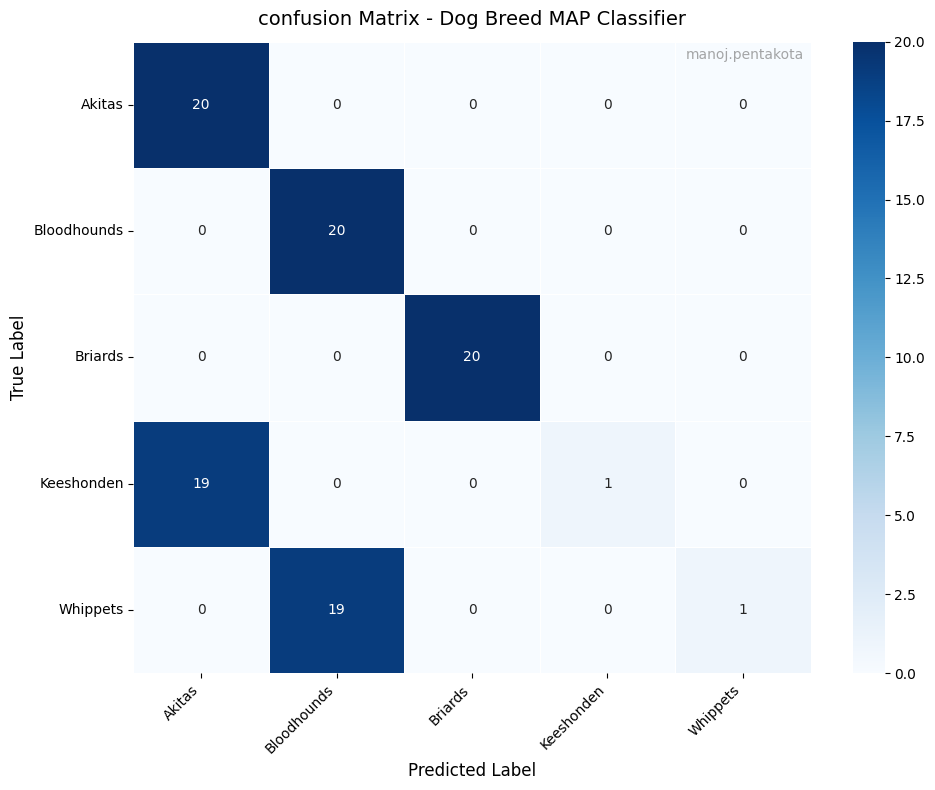

In [ ]:
unique_labels = sorted(train_df['breed'].unique())
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
metrics = precision_recall_f1(cm)

print(f"Macro Precision : {metrics['precision']:.4f}")
print(f"Macro Recall    : {metrics['recall']:.4f}")
print(f"Macro F1 Score  : {metrics['f1']:.4f}")

plot_confusion_matrix(cm, unique_labels, username="manoj.pentakota", title="confusion Matrix - Dog Breed MAP Classifier")

2.3 Spam Detection

In [ ]:
import pandas as pd
import numpy as np

username = "manoj.pentakota" # You can replace this with a dynamic username if available
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

def custom_train_test_split(df, test_size=0.2, seed=42):
  """
  custom train test split with 2.1 uniform sampler lcg_uniform_generator
  """
  n_samples = len(df)
  n_test = int (n_samples * test_size)

  random_scores = lcg_uniform_generator(0.0, 1.0, n_samples, seed)
  shuffled_indices = np.argsort(random_scores)

  test_indices = shuffled_indices[:n_test]
  train_indices = shuffled_indices[n_test:]


  train_df = df.iloc[train_indices].reset_index(drop=True)
  test_df = df.iloc[test_indices].reset_index(drop=True)

  return train_df, test_df

def fit_spam_counts(df):
  """
  fit spam/ham counts over training split
  returns:
  word_freq: {word: {"spam": s, "ham": h}}
  class_freq: {"spam": ..,"ham": ...}
  """

  label_col = 'Prediction'

  spam_df = df[df[label_col] == 1]
  ham_df = df[df[label_col] == 0]

  class_freq = {
      "spam": len(spam_df),
      "ham": len(ham_df)
  }

  ignore_cols = {'Email No.', 'Prediction'}
  word_cols = [c for c in df.columns if c not in ignore_cols]

  spam_doc_counts = (spam_df[word_cols]>0).sum(axis=0)
  ham_doc_counts = (ham_df[word_cols]>0).sum(axis=0)

  word_freq = {}
  for word in word_cols:
    word_freq[word] = {
        "spam": spam_doc_counts[word],
        "ham": ham_doc_counts[word]
    }

  return word_freq, class_freq

In [ ]:
# 2.3.2 Smoothed Classifier

def stable_sigmoid(t):
  """
  Numerically stable two-branch sigmoid to avoid overflow
  sigma(t) = 1/(1+exp(-t)) if t >= 0 else exp(t)/(1+exp(t))
  """
  if t >= 0:
    return 1 / (1 + np.exp(-t))
  else:
    return np.exp(t) / (1 + np.exp(t))

def naive_bayes_spam_prob(text, word_freq, class_freq, alpha=1.0):
  """
  compute P(spam | email)
  """
  present_words = set(text.lower().split())

  n_spam = class_freq["spam"]
  n_ham = class_freq["ham"]
  n_total = n_spam + n_ham

  score_spam = np.log(n_spam / n_total)
  score_ham = np.log(n_ham / n_total)

  for w in present_words:
    if w in word_freq:
      s_count = word_freq[w]["spam"]
      h_count = word_freq[w]["ham"]
      p_w_spam = (s_count + alpha) / (n_spam + 2*alpha)
      p_w_ham = (h_count + alpha) / (n_ham + 2*alpha)
      score_spam += np.log(p_w_spam)
      score_ham += np.log(p_w_ham)

  return stable_sigmoid(score_spam - score_ham)

Macro Precision : 0.8475
Macro Recall    : 0.9046
Macro F1 Score  : 0.8606


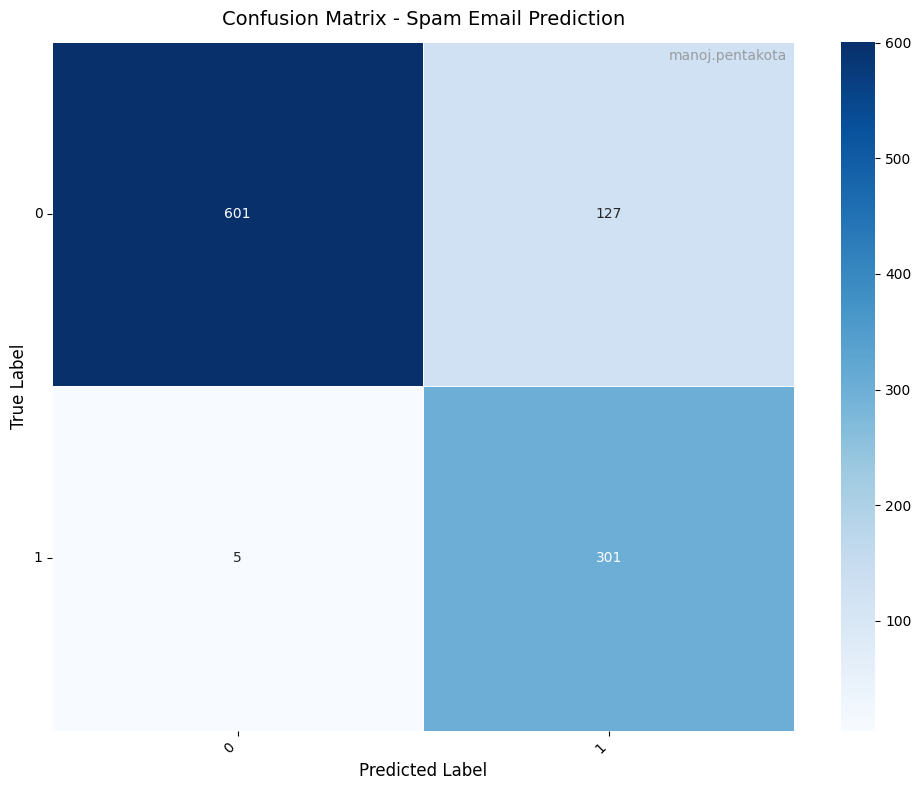

In [ ]:
# execution of 2.3
import hashlib

df_emails = pd.read_csv("/content/emails.csv")
username = "manoj.pentakota" # You can replace this with a dynamic username if available
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
train_df, test_df = custom_train_test_split(df_emails, test_size=0.2, seed=seed)
word_freq, class_freq = fit_spam_counts(train_df)

# testing on test set
ignore_cols = {'Email No.', 'Prediction'}
word_cols = [c for c in df_emails.columns if c not in ignore_cols]

test_probs = []
for _, row in test_df.iterrows():
  present_words = " ".join([w for w in word_cols if row[w]>0])
  prob = naive_bayes_spam_prob(present_words, word_freq, class_freq, alpha=1.0)
  test_probs.append(prob)

test_preds = [1 if p >= 0.5 else 0 for p in test_probs]
y_true_test = test_df['Prediction'].values


cm_spam = confusion_matrix(y_true_test, test_preds, labels=[0,1])
metrics_spam = precision_recall_f1(cm_spam)

print(f"Macro Precision : {metrics_spam['precision']:.4f}")
print(f"Macro Recall    : {metrics_spam['recall']:.4f}")
print(f"Macro F1 Score  : {metrics_spam['f1']:.4f}")

unique_labels = [0,1]
plot_confusion_matrix(cm_spam, unique_labels, username="manoj.pentakota", title="Confusion Matrix - Spam Email Prediction")

2.4 Bayesion Parameter Estimation

In [ ]:
import numpy as np
import pandas as pd
import scipy.special as sp
import hashlib

username = "manoj.pentakota" # You can replace this with a dynamic username if available
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

df_traits = pd.read_csv("breed_traits.csv")

SELECTED_BREEDS = [
    "Keeshonden",
    "Akitas",
    "Bloodhounds",
    "Whippets",
    "Briards"
]

breed_subset = df_traits[df_traits["Breed"].isin(SELECTED_BREEDS)].copy()

N_PER_BREED = 100
synthetic_rows = []

for idx, row in breed_subset.iterrows():
  breed_name = row["Breed"]
  bark_base = row["Barking Level"]
  p_bark = (bark_base - 0.5) / 5.0

  bark_samples = binomial_generator(n=30, p=p_bark, num_samples=N_PER_BREED, seed=seed)
  for i in range(N_PER_BREED):
    synthetic_rows.append({
        'breed' : breed_name,
        'barking_level' : bark_base,
        'p_true' : p_bark,
        'bark_days' : int(bark_samples[i])
    })

df_barking = pd.DataFrame(synthetic_rows)

train_df, test_df = stratified_train_test_split(df_barking, target_col='breed', test_size=0.2, seed=seed)

In [ ]:
def beta_binomial_posterior(alpha_prior, beta_prior, observations, n_trails):
  """
  compute conjugate beta posterior
  alpha_post = alpha_prior + sum_i(k_i)
  beta_post = beta_prior + sum_i(n - k_i)
  """
  obs = np.asarray(observations, dtype=float)
  sum_k = np.sum(obs)
  sum_n_minus_k = np.sum(n_trails - obs)
  alpha_post = alpha_prior + sum_k
  beta_post = beta_prior + sum_n_minus_k
  return alpha_post, beta_post

def posterior_point_estimates(alpha_post, beta_post):
  """
  computes mean, mode(MAP) and variance for the posterior

  mean = alpha / (alpha + beta)
  mode (MAP) = (alpha - 1) / (alpha + beta -2)
  variance = alpha * beta / (alpha + beta)**2 * (alpha + beta + 1)
  """
  mean = alpha_post / (alpha_post + beta_post)

  if alpha_post > 1 and beta_post > 1:
    mode = (alpha_post - 1) / (alpha_post + beta_post - 2)
  elif a > 1 and b  <= 1:
    mode = 1.0
  elif a <= 1 and b > 1:
    mode = 0.0
  else:
    mode = float("nan")

  variance = (alpha_post * beta_post) / ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1))

  return {"mean": mean,"mode": mode,"variance": variance}

def credible_interval(alpha_post, beta_post, level=0.95):
  """
  computes central credible interval using scipy.special.betaincinv
  """
  trail_prob = (1.0 - level) / 2.0
  lower_bound = trail_prob
  upper_bound = 1.0 - trail_prob
  ci_lower = sp.betaincinv(alpha_post, beta_post, lower_bound)
  ci_upper = sp.betaincinv(alpha_post, beta_post, upper_bound)

  return ci_lower, ci_upper

In [ ]:
# select a target breed
target_breed = train_df["breed"].unique()[0]
# full training split for the target breed
breed_full_obs = train_df[train_df["breed"] == target_breed]["bark_days"].values
# small training subset
breed_small_obs = breed_full_obs[:5]

# Raw MLE calculations: k_bar / n
mle_full = np.mean(breed_full_obs) / 30.0
mle_small = np.mean(breed_small_obs) / 30.0

print(f"Raw MLE Rate (Full Data, N={len(breed_full_obs)} dogs) : {mle_full:.4f}")
print(f"Raw MLE Rate (Small Data, N=5 dogs) : {mle_small:.4f}\n")

experiments = [
    ("Flat Prior Beta(1,1)", 1.0, 1.0, breed_full_obs, f"Full Dataset (N={len(breed_full_obs)})"),
    ("Flat Prior Beta(1,1)", 1.0, 1.0, breed_small_obs, "Small Dataset (N=5)"),
    ("Wrong Prior Beta(2,8)", 2.0, 8.0, breed_full_obs, f"Full Dataset (N={len(breed_full_obs)})"),
    ("Wrong Prior Beta(2,8)", 2.0, 8.0, breed_small_obs, "Small Dataset (N=5)"),
]

table_rows = []
for prior_name, a0, b0, obs, data_label in experiments:
    a_post, b_post = beta_binomial_posterior(a0, b0, obs, n_trails=30)
    estimates = posterior_point_estimates(a_post, b_post)
    ci_low, ci_high = credible_interval(a_post, b_post, level=0.95)

    table_rows.append({
        "Prior": prior_name,
        "Data Size": data_label,
        "Post Mean": f"{estimates['mean']:.4f}",
        "Post Mode": f"{estimates['mode']:.4f}",
        "Post Variance": f"{estimates['variance']:.6f}",
        "95% Credible Interval": f"({ci_low:.4f}, {ci_high:.4f})"
    })

results_df = pd.DataFrame(table_rows)
print(results_df.to_string(index=False))

Raw MLE Rate (Full Data, N=80 dogs) : 0.3258
Raw MLE Rate (Small Data, N=5 dogs) : 0.2467

                Prior           Data Size Post Mean Post Mode Post Variance 95% Credible Interval
 Flat Prior Beta(1,1) Full Dataset (N=80)    0.3260    0.3258      0.000091      (0.3074, 0.3449)
 Flat Prior Beta(1,1) Small Dataset (N=5)    0.2500    0.2467      0.001225      (0.1847, 0.3216)
Wrong Prior Beta(2,8) Full Dataset (N=80)    0.3253    0.3252      0.000091      (0.3068, 0.3441)
Wrong Prior Beta(2,8) Small Dataset (N=5)    0.2437    0.2405      0.001145      (0.1806, 0.3130)


Based on the above results we can observe that in:

1. Large training split (80 dogs, 2400 days)
the vast amount of data is complete dominating the calculations even so that a heavy biased prior like beta(2,8) is not effect much which we see by the comparisions betweens posterior mean which is 0.3253 which is very near to raw mle 0.3258

2. Small training split (5 dogs, 150 days):
small training data size allows the prior to show more weight in the result. the biased beta(2,8) prior acts as regularizer which is pulling the posterior mean down , while displaying high variance and hence a much wider interval.